In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned data
df = pd.read_json('data/processed/clean_user_events.jsonl', lines=True)
df['event_date'] = pd.to_datetime(df['event_date'])

In [3]:
dau = df.groupby('event_date')['user_id'].nunique()

In [4]:
# Calculate rolling mean and std for DAU
window = 7  # 7-day window
rolling_mean = dau.rolling(window).mean()
rolling_std = dau.rolling(window).std()

# Compute z-score
z_score = (dau - rolling_mean) / rolling_std

# Flag anomalies where z-score > 2 or < -2
anomalies = dau[(z_score > 2) | (z_score < -2)]


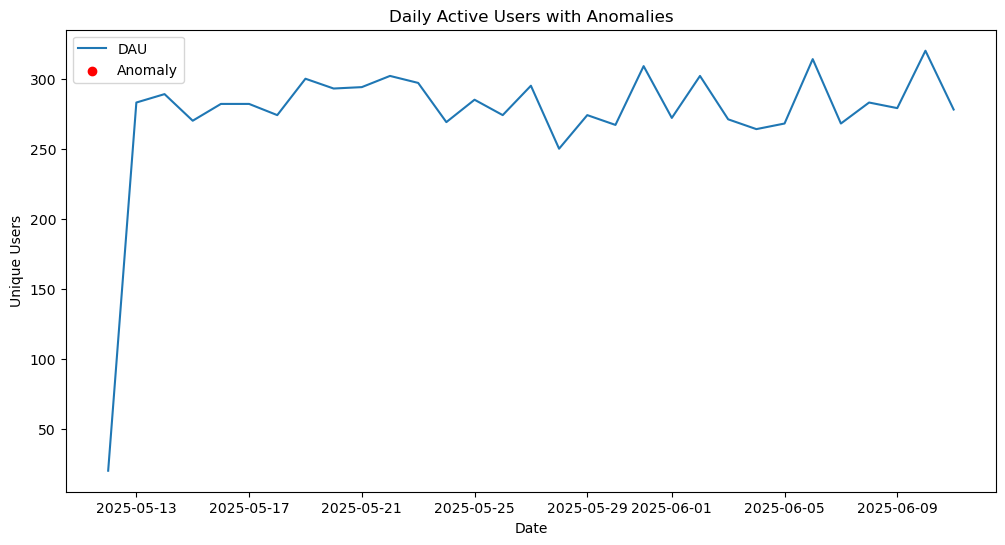

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(dau.index, dau.values, label='DAU')
plt.scatter(anomalies.index, anomalies.values, color='red', label='Anomaly', zorder=5)
plt.title('Daily Active Users with Anomalies')
plt.xlabel('Date')
plt.ylabel('Unique Users')
plt.legend()
plt.show()

In [6]:
# Pick an anomaly date to investigate
if not anomalies.empty:
    anomaly_date = anomalies.index[0]
    print(f"Investigating anomaly on {anomaly_date.date()}")

    # Segment by device
    device_counts = df[df['event_date'] == anomaly_date].groupby('device')['user_id'].nunique()
    print("User count by device on anomaly date:\n", device_counts)

    # Segment by region
    region_counts = df[df['event_date'] == anomaly_date].groupby('region')['user_id'].nunique()
    print("User count by region on anomaly date:\n", region_counts)

    # Segment by event_type
    event_counts = df[df['event_date'] == anomaly_date]['event_type'].value_counts()
    print("Event type counts on anomaly date:\n", event_counts)
